In [30]:
import os 
import numpy as np
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms 
from torchvision.models import mobilenet_v2, efficientnet_b0

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
num_classes = 10
image_size = 224
in_channels = 3
batch_size = 32
epochs = 15

# CUDA Check
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

True
12.1
NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [32]:
IMG_CLASSES = "./IMG_CLASSES"
all_images = []
all_labels = []
sizes = []
counts = Counter()
counts_ext = Counter()

class_names = sorted(os.listdir(IMG_CLASSES))
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(IMG_CLASSES, class_name)
    if not os.path.isdir(class_dir):
        continue

    for img_name in os.listdir(class_dir):
        ext = os.path.splitext(img_name)[1].lower()
        if ext:
            counts_ext[ext] += 1

        if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            img_path = os.path.join(class_dir, img_name)
            all_images.append(img_path)
            all_labels.append(class_to_idx[class_name])
            counts[class_name] += 1
            img = Image.open(img_path)
            sizes.append(img.size)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(f"Total Images: {len(all_images)}")
print(f"Number of Classes: {len(class_names)}")

print("\nFormat distribution:")
for ext, count in counts_ext.most_common():
    print(f"  {ext}: {count}")

print("\nClass distribution:")
for k, v in counts.items():
    print(f"  {k}: {v}")

widths, heights = zip(*sizes)
print(f"\nImage sizes:")
print(f"  Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"  Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

Total Images: 27153
Number of Classes: 10

Format distribution:
  .jpg: 27153

Class distribution:
  1. Eczema 1677: 1677
  10. Warts Molluscum and other Viral Infections - 2103: 2103
  2. Melanoma 15.75k: 3140
  3. Atopic Dermatitis - 1.25k: 1257
  4. Basal Cell Carcinoma (BCC) 3323: 3323
  5. Melanocytic Nevi (NV) - 7970: 7970
  6. Benign Keratosis-like Lesions (BKL) 2624: 2079
  7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2055
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 1847
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 1702

Image sizes:
  Width  — min: 294, max: 1024, mean: 679
  Height — min: 222, max: 1128, mean: 570


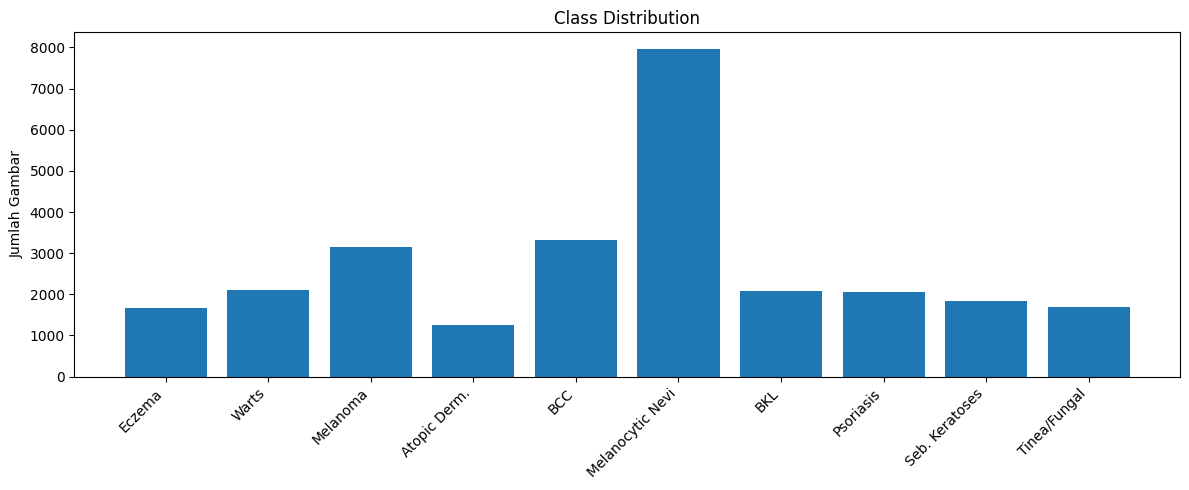

In [33]:
short_names = [
    "Eczema", "Warts", "Melanoma", 
    "Atopic Derm.", "BCC", "Melanocytic Nevi",
    "BKL", "Psoriasis", "Seb. Keratoses",
    "Tinea/Fungal"
]

plt.figure(figsize=(12, 5))
plt.bar(range(len(counts)), [counts[c] for c in class_names])
plt.xticks(range(len(counts)), short_names, rotation=45, ha='right')
plt.ylabel("Jumlah Gambar")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

In [34]:
max_count = max(counts.values())
min_count = min(counts.values())
print(f"Imbalance ratio: {max_count / min_count:.2f}x")

ratios = [w/h for w, h in sizes]
print(f"Aspect ratio — min: {min(ratios):.2f}, max: {max(ratios):.2f}, mean: {np.mean(ratios):.2f}")

Imbalance ratio: 6.34x
Aspect ratio — min: 0.62, max: 1.63, mean: 1.24


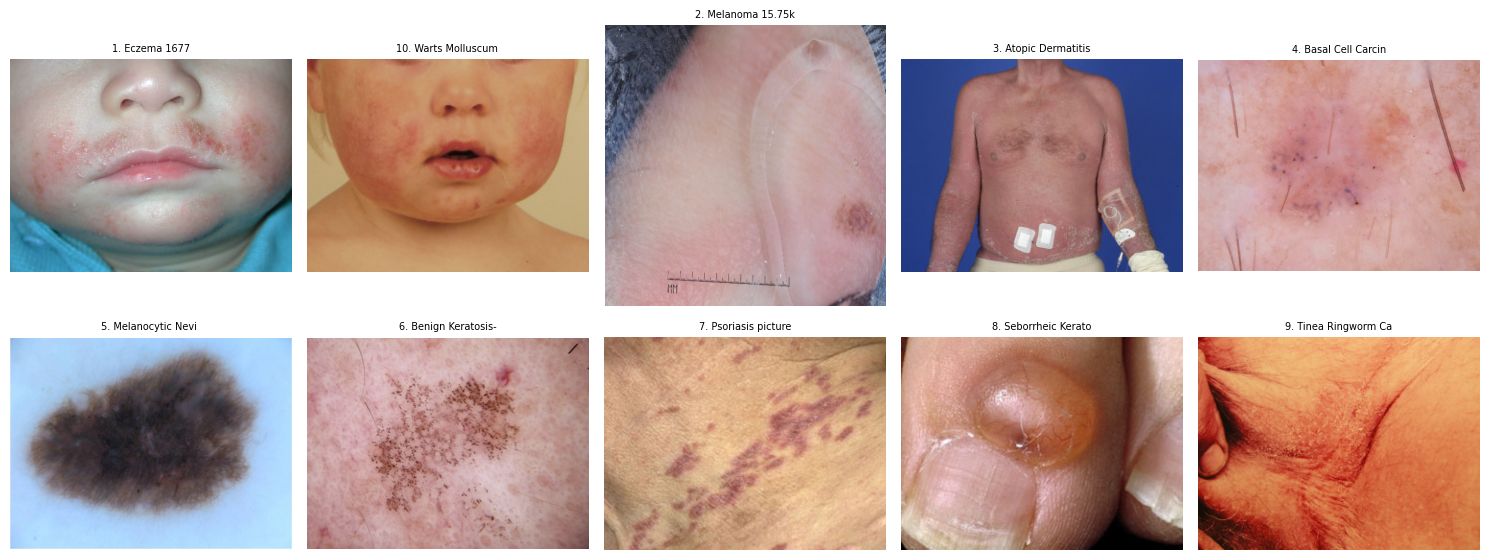

In [35]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, class_name in zip(axes.flatten(), class_names):
    class_dir = os.path.join(IMG_CLASSES, class_name)
    img_name = os.listdir(class_dir)[0]
    img = Image.open(os.path.join(class_dir, img_name))
    ax.imshow(img)
    ax.set_title(class_name[:20], fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [36]:
# Split Data

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_images, 
    all_labels,
    test_size = 0.2,
    stratify = all_labels,
    random_state = 42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size = 0.5,
    stratify = temp_labels,
    random_state = 42
)

In [37]:
# Dataset

class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        label = self.labels[idx]
        return img, label

In [38]:
temp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

temp_dataset = ImageDataset(all_images, all_labels, temp_transform)
temp_loader = DataLoader(temp_dataset, batch_size=batch_size, shuffle=False)

mean = torch.zeros(3)
var = torch.zeros(3)
total = 0

for imgs, _ in temp_loader:
    imgs = imgs.view(imgs.size(0), 3, -1)
    mean += imgs.mean(2).sum(0)
    var += imgs.var(2).sum(0)
    total += imgs.size(0)

mean /= total
std = torch.sqrt(var / total)
print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: tensor([0.6620, 0.4988, 0.4817])
Std: tensor([0.1619, 0.1485, 0.1517])


In [39]:
# Transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale = (0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), 
    transforms.RandomRotation(15), 
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), 
                         std.tolist())
])

val_transform = transforms.Compose([
    transforms.Resize(256), 
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), 
                         std.tolist())
])

In [40]:


train_dataset = ImageDataset(train_paths, train_labels, train_transform)
val_dataset = ImageDataset(val_paths, val_labels, val_transform)
test_dataset = ImageDataset(test_paths, test_labels, val_transform)

# WeightedRandomSampler

class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [41]:
# Data Loader

train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    sampler = sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size = batch_size,
    shuffle = False
)
 
test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle = False
)

In [42]:
# CNN

class CNN(nn.Module):
    def __init__(self, num_classes = num_classes):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding = 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        feature_size = image_size // (2**3)
        
        self.flatten = nn.Flatten()
        
        self.classifier = nn.Sequential(
            nn.Linear(128 * feature_size * feature_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        
        x = self.flatten(x)
        
        return self.classifier(x)

In [43]:
def train_model(model, model_name, epochs=epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    print("CUDA AVAILABLE:", torch.cuda.is_available())
    print("MODEL DEVICE:", next(model.parameters()).device)

    save_path = f"best_{model_name}.pth"

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, pred = torch.max(outputs, 1)
                val_correct += (pred == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch: {epoch+1}, Train Loss: {train_loss:.2f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.2f}, Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    # Load best & test eval
    model.load_state_dict(torch.load(save_path))
    model.eval()

    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            test_correct += (predicted == labels).sum().item()
            test_total += labels.size(0)

    test_acc = 100 * test_correct / test_total
    print(f"\n[{model_name}] Test Accuracy: {test_acc:.2f}%")

    return train_losses, val_losses

In [44]:
# Inference Function

def evaluate_model(model, test_loader, device = None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
    model.to(device)
    model.eval()
 
    all_preds = []
    all_labels = []
    all_probs = []
 
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
 
            _, preds = torch.max(outputs, 1)
 
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
 
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [45]:
#  Train CNN

print("Training CNN...\n")

cnn = CNN()

cnn_train, cnn_val = train_model(cnn, "cnn")

Training CNN...

CUDA AVAILABLE: True
MODEL DEVICE: cuda:0
Epoch: 1, Train Loss: 2.87, Train Acc: 18.25%, Val Loss: 1.56, Val Acc: 38.20%
Epoch: 2, Train Loss: 1.96, Train Acc: 20.82%, Val Loss: 1.59, Val Acc: 34.11%
Epoch: 3, Train Loss: 1.93, Train Acc: 22.01%, Val Loss: 1.51, Val Acc: 38.31%
Epoch: 4, Train Loss: 1.89, Train Acc: 23.46%, Val Loss: 1.50, Val Acc: 39.85%
Epoch: 5, Train Loss: 1.84, Train Acc: 24.77%, Val Loss: 1.65, Val Acc: 29.13%
Epoch: 6, Train Loss: 1.81, Train Acc: 26.02%, Val Loss: 1.44, Val Acc: 41.25%
Epoch: 7, Train Loss: 1.75, Train Acc: 28.72%, Val Loss: 1.40, Val Acc: 42.21%
Epoch: 8, Train Loss: 1.72, Train Acc: 28.97%, Val Loss: 1.32, Val Acc: 48.80%
Epoch: 9, Train Loss: 1.70, Train Acc: 29.79%, Val Loss: 1.40, Val Acc: 42.28%
Epoch: 10, Train Loss: 1.67, Train Acc: 31.72%, Val Loss: 1.29, Val Acc: 47.15%
Epoch: 11, Train Loss: 1.64, Train Acc: 32.69%, Val Loss: 1.29, Val Acc: 47.11%
Epoch: 12, Train Loss: 1.61, Train Acc: 34.03%, Val Loss: 1.28, Val Ac

C:\Users\User\AppData\Local\Temp\ipykernel_33156\3396326731.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))



[cnn] Test Accuracy: 56.70%


In [46]:
# Train MobileNet

print("Training MobileNet...\n")

mobilenet = mobilenet_v2(pretrained = True)
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, num_classes)

mobilenet_train, mobilenet_val = train_model(mobilenet, "mobilenet")

Training MobileNet...



c:\Users\User\anaconda3\envs\deep_learning\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\deep_learning\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


CUDA AVAILABLE: True
MODEL DEVICE: cuda:0
Epoch: 1, Train Loss: 1.27, Train Acc: 50.62%, Val Loss: 1.07, Val Acc: 56.24%
Epoch: 2, Train Loss: 1.05, Train Acc: 59.82%, Val Loss: 0.79, Val Acc: 69.83%
Epoch: 3, Train Loss: 0.98, Train Acc: 62.56%, Val Loss: 0.79, Val Acc: 69.47%
Epoch: 4, Train Loss: 0.93, Train Acc: 64.90%, Val Loss: 0.77, Val Acc: 71.93%
Epoch: 5, Train Loss: 0.90, Train Acc: 66.32%, Val Loss: 0.93, Val Acc: 64.79%
Epoch: 6, Train Loss: 0.87, Train Acc: 67.14%, Val Loss: 0.77, Val Acc: 71.82%
Epoch: 7, Train Loss: 0.83, Train Acc: 69.11%, Val Loss: 0.77, Val Acc: 72.45%
Epoch: 8, Train Loss: 0.80, Train Acc: 70.05%, Val Loss: 0.78, Val Acc: 70.87%
Epoch: 9, Train Loss: 0.78, Train Acc: 70.69%, Val Loss: 0.76, Val Acc: 72.67%
Epoch: 10, Train Loss: 0.76, Train Acc: 71.60%, Val Loss: 0.77, Val Acc: 73.04%
Epoch: 11, Train Loss: 0.74, Train Acc: 72.63%, Val Loss: 0.84, Val Acc: 69.76%
Epoch: 12, Train Loss: 0.72, Train Acc: 73.30%, Val Loss: 0.71, Val Acc: 73.15%
Epoch: 

C:\Users\User\AppData\Local\Temp\ipykernel_33156\3396326731.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))



[mobilenet] Test Accuracy: 75.07%


In [47]:
# Train EfficientNet

print("Training EfficientNet...\n")

efficientnet = efficientnet_b0(pretrained = True)
efficientnet.classifier[1] = nn.Linear(1280, num_classes)

efficientnet_train, efficientnet_val = train_model(efficientnet, "efficientnet")


Training EfficientNet...



c:\Users\User\anaconda3\envs\deep_learning\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


CUDA AVAILABLE: True
MODEL DEVICE: cuda:0
Epoch: 1, Train Loss: 1.10, Train Acc: 58.48%, Val Loss: 0.79, Val Acc: 69.65%
Epoch: 2, Train Loss: 0.85, Train Acc: 68.52%, Val Loss: 0.68, Val Acc: 75.73%
Epoch: 3, Train Loss: 0.74, Train Acc: 72.71%, Val Loss: 0.62, Val Acc: 76.98%
Epoch: 4, Train Loss: 0.67, Train Acc: 75.56%, Val Loss: 0.59, Val Acc: 78.27%
Epoch: 5, Train Loss: 0.60, Train Acc: 78.01%, Val Loss: 0.72, Val Acc: 74.70%
Epoch: 6, Train Loss: 0.54, Train Acc: 80.48%, Val Loss: 0.62, Val Acc: 79.82%
Epoch: 7, Train Loss: 0.50, Train Acc: 82.08%, Val Loss: 0.67, Val Acc: 78.05%
Epoch: 8, Train Loss: 0.46, Train Acc: 83.33%, Val Loss: 0.62, Val Acc: 80.33%
Epoch: 9, Train Loss: 0.42, Train Acc: 84.77%, Val Loss: 0.62, Val Acc: 80.33%
Epoch: 10, Train Loss: 0.39, Train Acc: 86.14%, Val Loss: 0.65, Val Acc: 80.55%
Epoch: 11, Train Loss: 0.35, Train Acc: 87.66%, Val Loss: 0.67, Val Acc: 80.59%
Epoch: 12, Train Loss: 0.34, Train Acc: 88.07%, Val Loss: 0.68, Val Acc: 78.90%
Epoch: 

C:\Users\User\AppData\Local\Temp\ipykernel_33156\3396326731.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))



[efficientnet] Test Accuracy: 81.59%


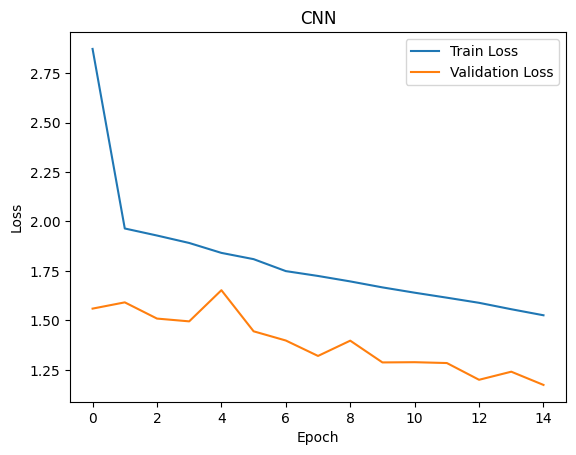

In [48]:
# Plot CNN

plt.plot(cnn_train, label = "Train Loss")
plt.plot(cnn_val, label = "Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN")

plt.legend()
plt.show()

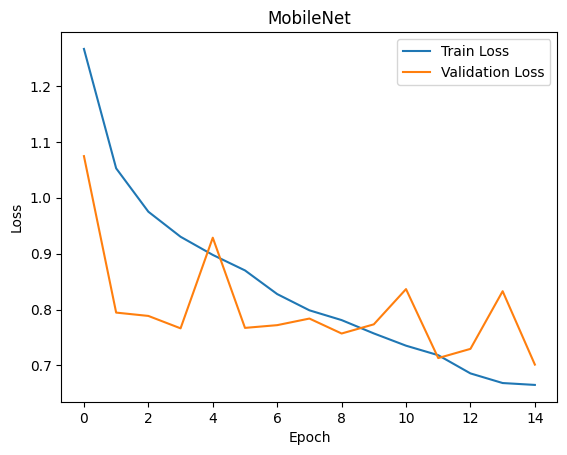

In [49]:
# Plot MobileNet

plt.plot(mobilenet_train, label = "Train Loss")
plt.plot(mobilenet_val, label = "Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNet")

plt.legend()
plt.show()

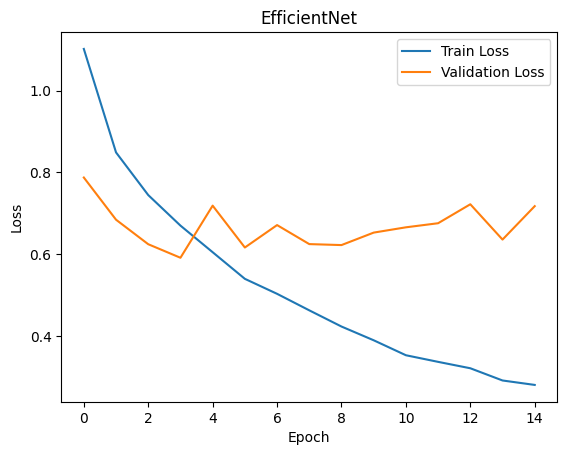

In [50]:
# Plot EfficientNet

plt.plot(efficientnet_train, label = "Train Loss")
plt.plot(efficientnet_val, label = "Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet")

plt.legend()
plt.show()

In [51]:
# Primary Metrics

def print_primary_metrics(preds, labels, model_name):
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average = "macro", zero_division = 0)
    rec = recall_score(labels, preds, average = "macro", zero_division = 0)
    f1 = f1_score(labels, preds, average = "macro", zero_division = 0)
 
    print(f"\n{'='*50}")
    print(f" {model_name} - Primary Metrics")
    print(f"{'='*50}")
    print(f" Accuracy:          {acc:.4f}")
    print(f" Precision (macro): {prec:.4f}")
    print(f" Recall (macro):    {rec:.4f}")
    print(f" F1 Score (macro):  {f1:.4f}")
    print(f"{'='*50}")
 
    print(f"\nPer-Class Report:\n")
    print(classification_report(labels, preds, target_names = class_names, zero_division = 0))
 
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [52]:
# Confusion Matrix
 
def plot_confusion_matrix(preds, labels, model_name):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype("float") / cm.sum(axis = 1, keepdims = True)

    fig, axes = plt.subplots(1, 2, figsize = (22, 9))

    sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = short_names, yticklabels = short_names, ax = axes[0], annot_kws = {"size": 8})
    axes[0].set_title(f"{model_name} - Confusion Matrix (Counts)")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].tick_params(axis = 'x', rotation = 45)
    axes[0].tick_params(axis = 'y', rotation = 0)

    sns.heatmap(cm_norm, annot = True, fmt = ".2f", cmap = "Blues", xticklabels = short_names, yticklabels = short_names, ax = axes[1], annot_kws = {"size": 8})
    axes[1].set_title(f"{model_name} - Confusion Matrix (Normalized)")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    axes[1].tick_params(axis = 'x', rotation = 45)
    axes[1].tick_params(axis = 'y', rotation = 0)

    fig.add_artist(plt.Line2D([0.49, 0.49], [0.05, 0.95], transform = fig.transFigure, color = 'black', linewidth = 1.5))
    plt.tight_layout()
    plt.show()

In [53]:
# ROC Curve & AUC (Per Class) 
 
def plot_roc_auc(probs, labels, model_name):
    n_classes = probs.shape[1]
 
    labels_bin = np.zeros((len(labels), n_classes))
    for i, l in enumerate(labels):
        labels_bin[i, l] = 1
 
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
 
    auc_scores = {}
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores[class_names[i]] = roc_auc
        ax.plot(fpr, tpr, label = f"{short_names[i]} (AUC = {roc_auc:.3f})")
 
    ax.plot([0, 1], [0, 1], "k--", alpha = 0.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{model_name} - ROC Curve (Per Class)")
    ax.legend(loc = "lower right", fontsize = 8)
    plt.tight_layout()
    plt.show()
 
    macro_auc = np.mean(list(auc_scores.values()))
    print(f"\n{model_name} - AUC Scores:")
    for cls, score in auc_scores.items():
        print(f"  {cls}: {score:.4f}")
    print(f"  Macro AUC: {macro_auc:.4f}")
 
    return auc_scores

In [54]:
# GradCAM

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
 
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)
 
    def _forward_hook(self, module, input, output):
        self.activations = output.detach()
 
    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
 
    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
 
        if target_class is None:
            target_class = output.argmax(dim=1).item()
 
        self.model.zero_grad()
        target = output[0, target_class]
        target.backward()
 
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
 
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
 
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
 
        cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
 
        return cam.squeeze().cpu().numpy(), target_class
 
 
def get_target_layer(model, model_name):
    """Get the last conv layer for Grad-CAM."""
    if model_name == "CNN":
        return model.conv3[0]  
    elif model_name == "MobileNet":
        return model.features[-1] 
    elif model_name == "EfficientNet":
        return model.features[-1][0]  
    else:
        raise ValueError(f"Unknown model: {model_name}")
 
 
def plot_gradcam_samples(model, model_name, test_paths, test_labels, 
                         val_transform, class_names, n_samples=8):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
 
    target_layer = get_target_layer(model, model_name)
    grad_cam = GradCAM(model, target_layer)
 
    inv_normalize = transforms.Compose([
        transforms.Normalize(mean=[0., 0., 0.], std=[1/s for s in std.tolist()]),
        transforms.Normalize(mean=[-m for m in mean.tolist()], std=[1., 1., 1.])
    ])
 
    indices = np.random.choice(len(test_paths), n_samples, replace=False)
 
    fig, axes = plt.subplots(2, n_samples, figsize=(3 * n_samples, 6))
 
    for col, idx in enumerate(indices):
        img = Image.open(test_paths[idx]).convert("RGB")
        input_tensor = val_transform(img).unsqueeze(0).to(device)
        true_label = test_labels[idx]
 
        cam, pred_class = grad_cam.generate(input_tensor)
 
        img_display = inv_normalize(input_tensor.squeeze()).cpu()
        img_display = img_display.permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)
 
        axes[0, col].imshow(img_display)
        color = "green" if pred_class == true_label else "red"
        axes[0, col].set_title(
            f"True: {class_names[true_label]}\nPred: {class_names[pred_class]}",
            fontsize=8, color=color
        )
        axes[0, col].axis("off")
 
        axes[1, col].imshow(img_display)
        axes[1, col].imshow(cam, cmap="jet", alpha=0.5)
        axes[1, col].set_title("Grad-CAM", fontsize=8)
        axes[1, col].axis("off")
 
    fig.suptitle(f"{model_name} - Grad-CAM Visualization", fontsize=14)
    plt.tight_layout()
    plt.show()


In [55]:
# Per-Class Error Analysis
 
def per_class_error_analysis(preds, labels, probs, model_name):
    n_classes = len(class_names)
 
    print(f"\n{'='*60}")
    print(f" {model_name} - Per-Class Error Analysis")
    print(f"{'='*60}")
 
    cm = confusion_matrix(labels, preds)
 
    for i in range(n_classes):
        total = np.sum(labels == i)
        correct = cm[i, i]
        wrong = total - correct
        acc = correct / total if total > 0 else 0
 
        print(f"\n  {class_names[i]} ({total} samples):")
        print(f"    Accuracy: {acc:.4f} | Correct: {correct} | Wrong: {wrong}")
 
        if wrong > 0:
            misclassified_as = []
            for j in range(n_classes):
                if j != i and cm[i, j] > 0:
                    misclassified_as.append((class_names[j], cm[i, j]))
 
            misclassified_as.sort(key = lambda x: x[1], reverse = True)
            top_confusions = misclassified_as[:3]
            confusion_str = ", ".join([f"{name}: {count}" for name, count in top_confusions])
            print(f"    Most confused with -> {confusion_str}")
 
            mask_wrong = (labels == i) & (preds != labels)
            if np.any(mask_wrong):
                wrong_confs = probs[mask_wrong]
                avg_wrong_conf = np.mean(np.max(wrong_confs, axis = 1))
                print(f"    Avg confidence on wrong predictions: {avg_wrong_conf:.4f}")


 CNN - Primary Metrics
 Accuracy:          0.5670
 Precision (macro): 0.4285
 Recall (macro):    0.4595
 F1 Score (macro):  0.4277

Per-Class Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.28      0.61      0.38       167
           10. Warts Molluscum and other Viral Infections - 2103       0.26      0.12      0.16       211
                                              2. Melanoma 15.75k       0.91      0.75      0.83       314
                                    3. Atopic Dermatitis - 1.25k       0.22      0.41      0.28       125
                              4. Basal Cell Carcinoma (BCC) 3323       0.60      0.86      0.70       333
                                 5. Melanocytic Nevi (NV) - 7970       0.85      0.81      0.83       797
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.37      0.32      0.34       208

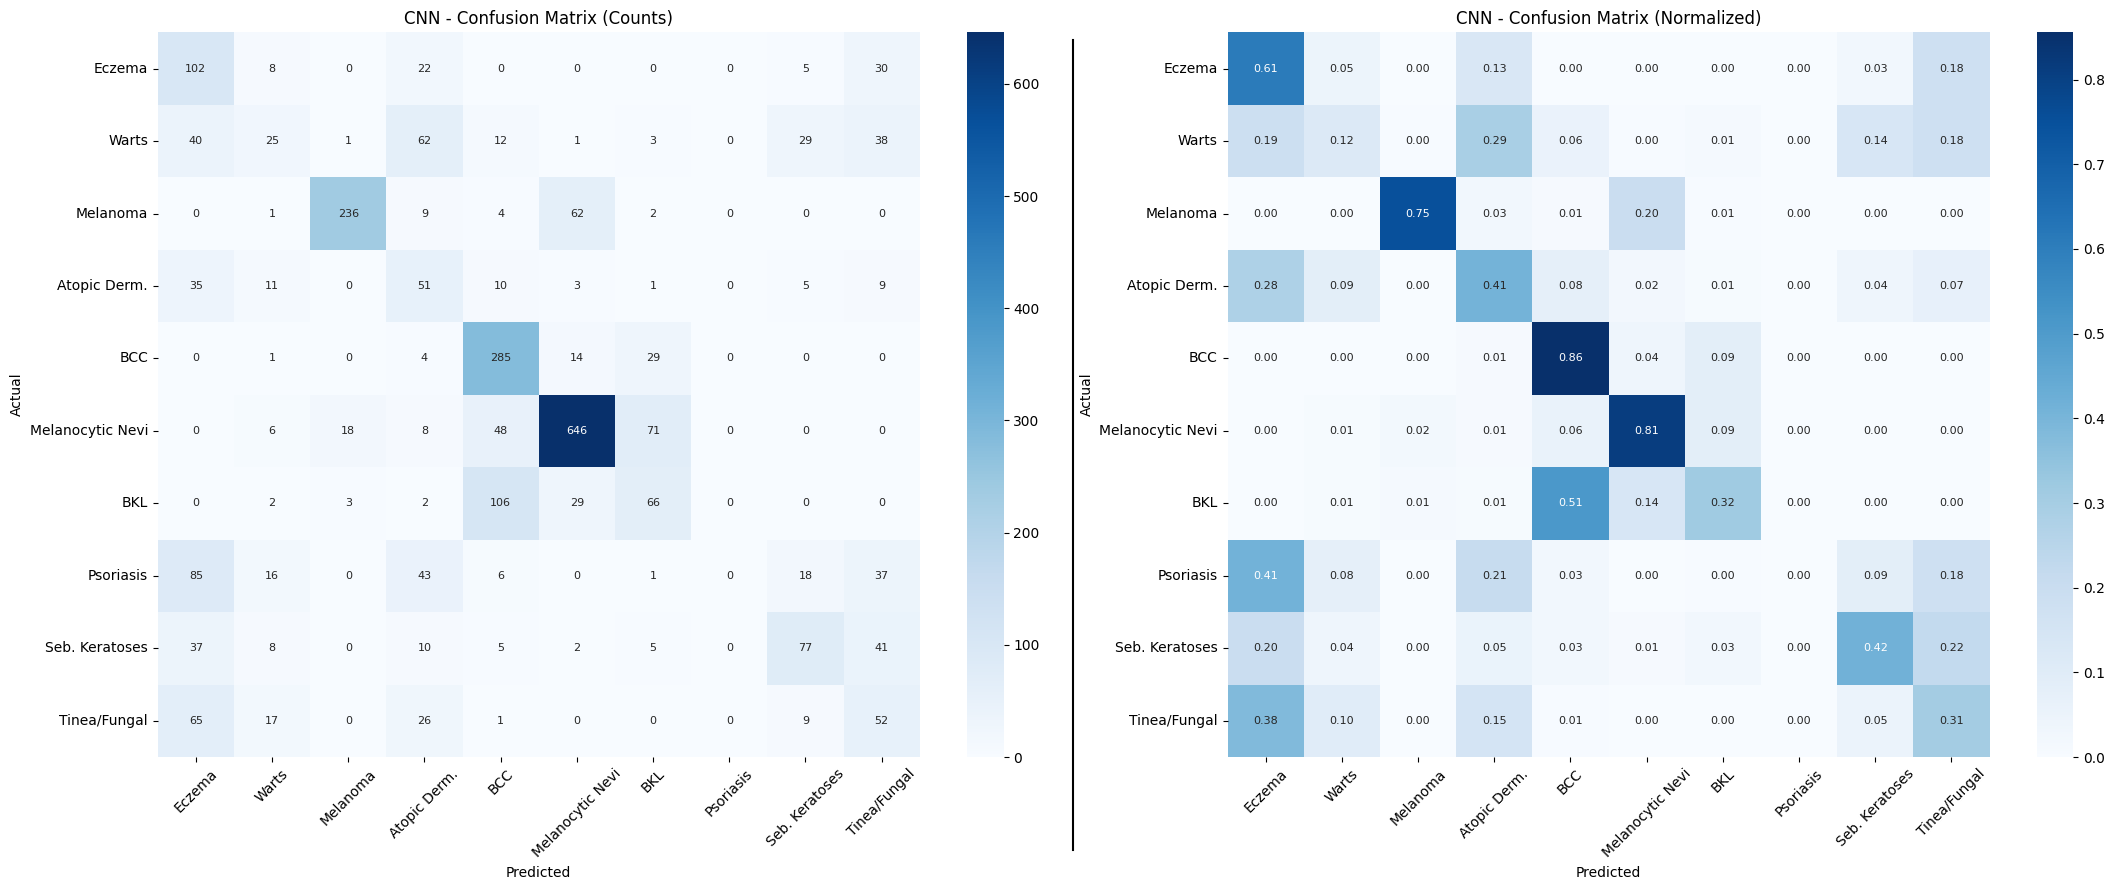

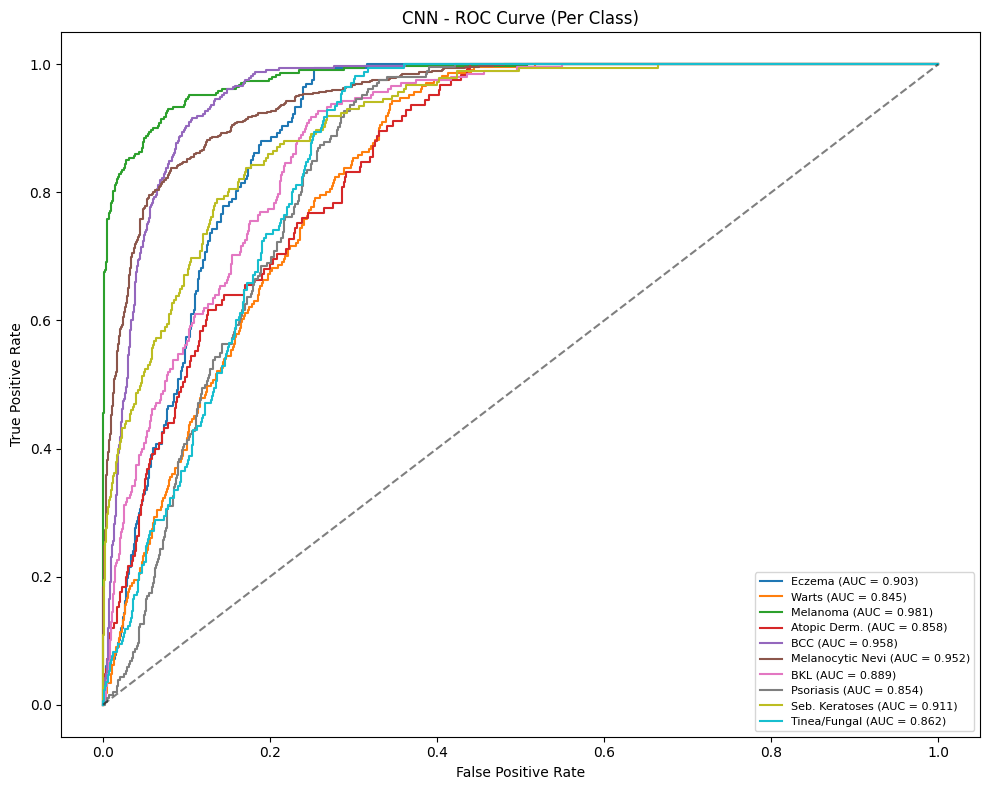


CNN - AUC Scores:
  1. Eczema 1677: 0.9027
  10. Warts Molluscum and other Viral Infections - 2103: 0.8455
  2. Melanoma 15.75k: 0.9810
  3. Atopic Dermatitis - 1.25k: 0.8582
  4. Basal Cell Carcinoma (BCC) 3323: 0.9580
  5. Melanocytic Nevi (NV) - 7970: 0.9524
  6. Benign Keratosis-like Lesions (BKL) 2624: 0.8892
  7. Psoriasis pictures Lichen Planus and related diseases - 2k: 0.8536
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 0.9113
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 0.8625
  Macro AUC: 0.9014

 CNN - Per-Class Error Analysis

  1. Eczema 1677 (167 samples):
    Accuracy: 0.6108 | Correct: 102 | Wrong: 65
    Most confused with -> 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 30, 3. Atopic Dermatitis - 1.25k: 22, 10. Warts Molluscum and other Viral Infections - 2103: 8
    Avg confidence on wrong predictions: 0.2150

  10. Warts Molluscum and other Viral Infections - 2103 (211 samples):
    Accuracy: 0.1185 | Correct

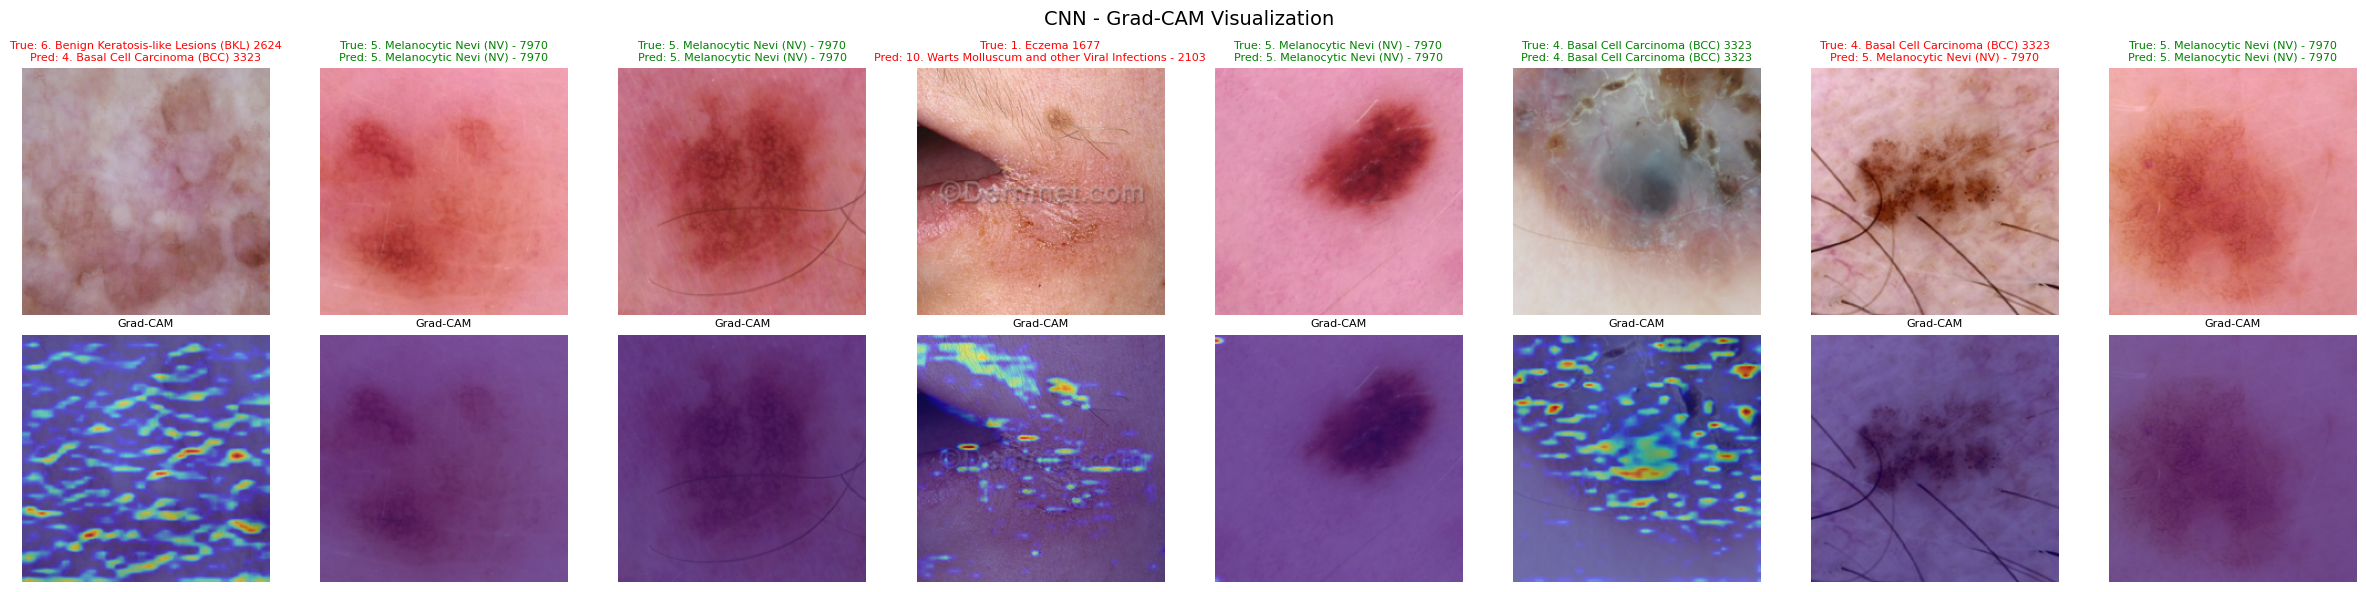


 MobileNet - Primary Metrics
 Accuracy:          0.7507
 Precision (macro): 0.6686
 Recall (macro):    0.6829
 F1 Score (macro):  0.6732

Per-Class Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.49      0.57      0.53       167
           10. Warts Molluscum and other Viral Infections - 2103       0.61      0.64      0.63       211
                                              2. Melanoma 15.75k       0.92      0.97      0.95       314
                                    3. Atopic Dermatitis - 1.25k       0.42      0.50      0.46       125
                              4. Basal Cell Carcinoma (BCC) 3323       0.81      0.92      0.86       333
                                 5. Melanocytic Nevi (NV) - 7970       0.98      0.84      0.91       797
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.63      0.74      0.68    

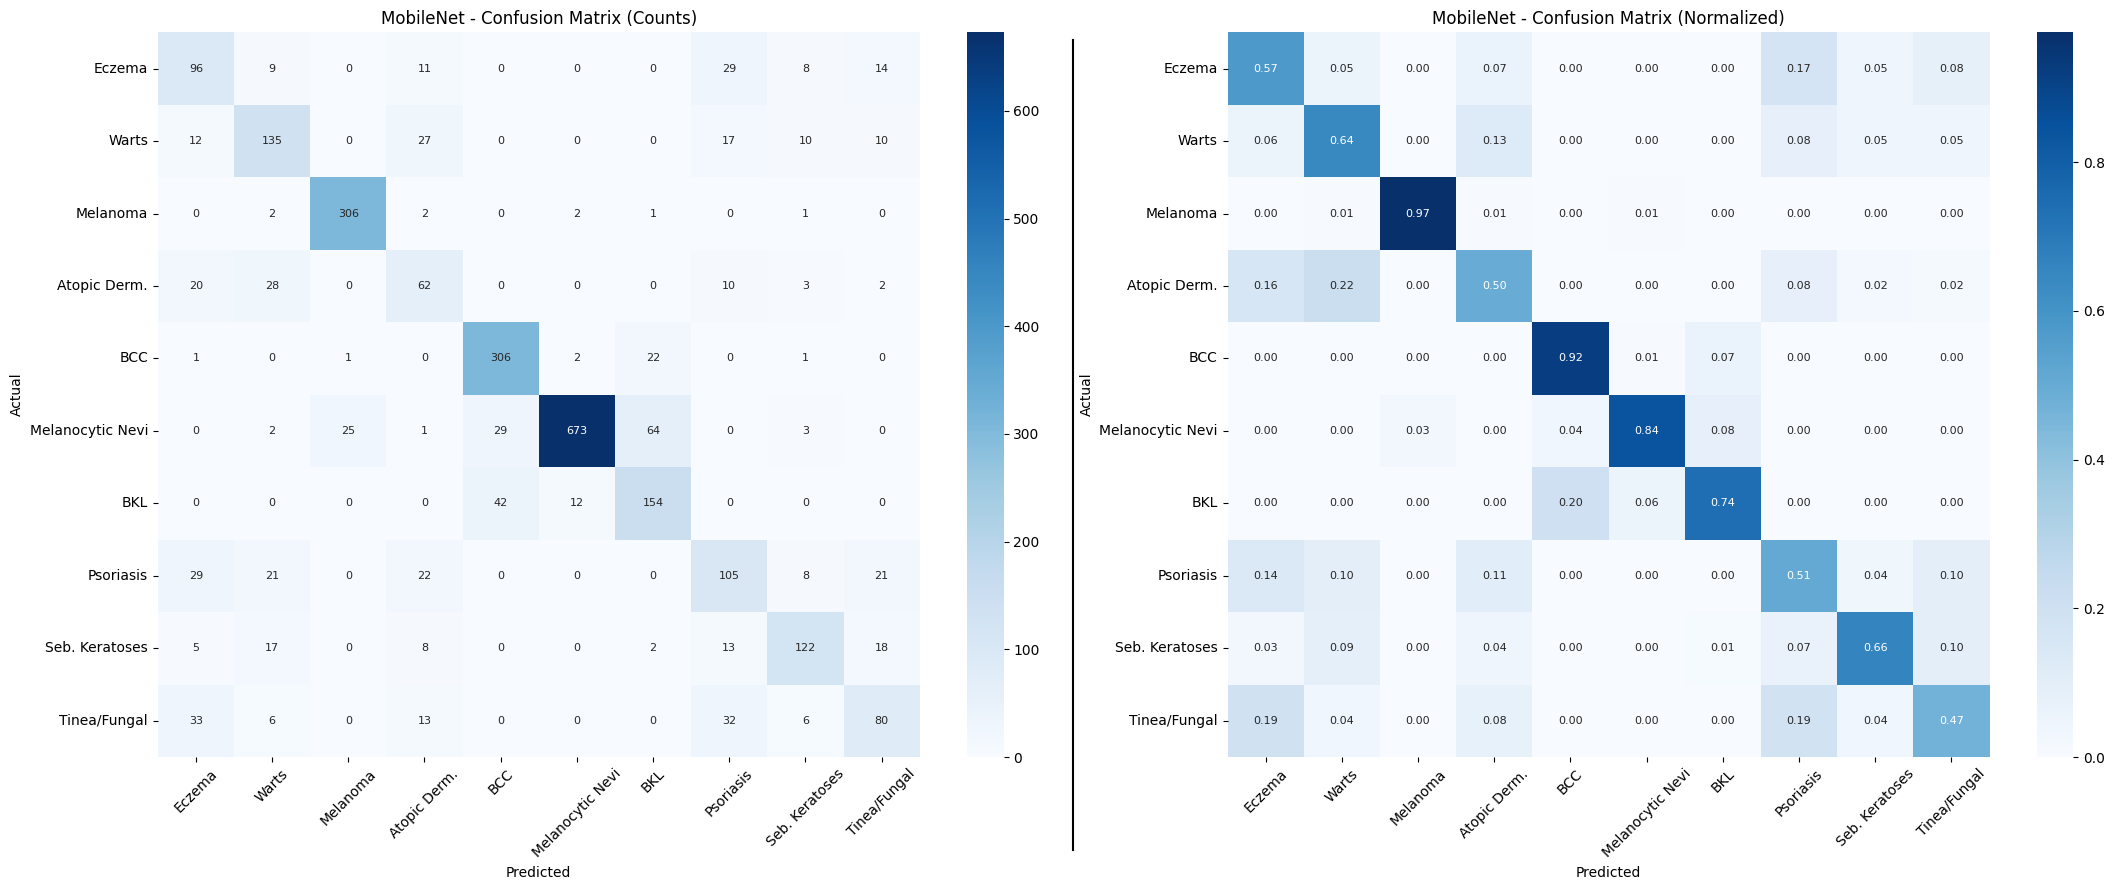

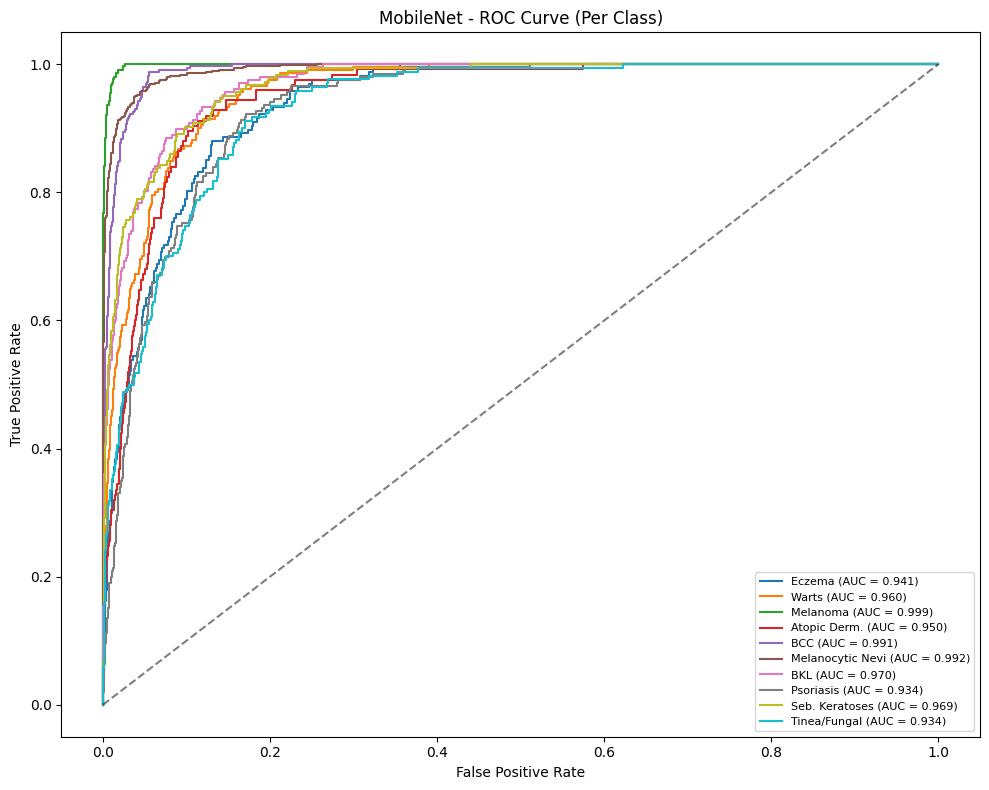


MobileNet - AUC Scores:
  1. Eczema 1677: 0.9407
  10. Warts Molluscum and other Viral Infections - 2103: 0.9602
  2. Melanoma 15.75k: 0.9987
  3. Atopic Dermatitis - 1.25k: 0.9505
  4. Basal Cell Carcinoma (BCC) 3323: 0.9907
  5. Melanocytic Nevi (NV) - 7970: 0.9925
  6. Benign Keratosis-like Lesions (BKL) 2624: 0.9701
  7. Psoriasis pictures Lichen Planus and related diseases - 2k: 0.9345
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 0.9688
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 0.9338
  Macro AUC: 0.9640

 MobileNet - Per-Class Error Analysis

  1. Eczema 1677 (167 samples):
    Accuracy: 0.5749 | Correct: 96 | Wrong: 71
    Most confused with -> 7. Psoriasis pictures Lichen Planus and related diseases - 2k: 29, 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 14, 3. Atopic Dermatitis - 1.25k: 11
    Avg confidence on wrong predictions: 0.6103

  10. Warts Molluscum and other Viral Infections - 2103 (211 samples):
    Accura

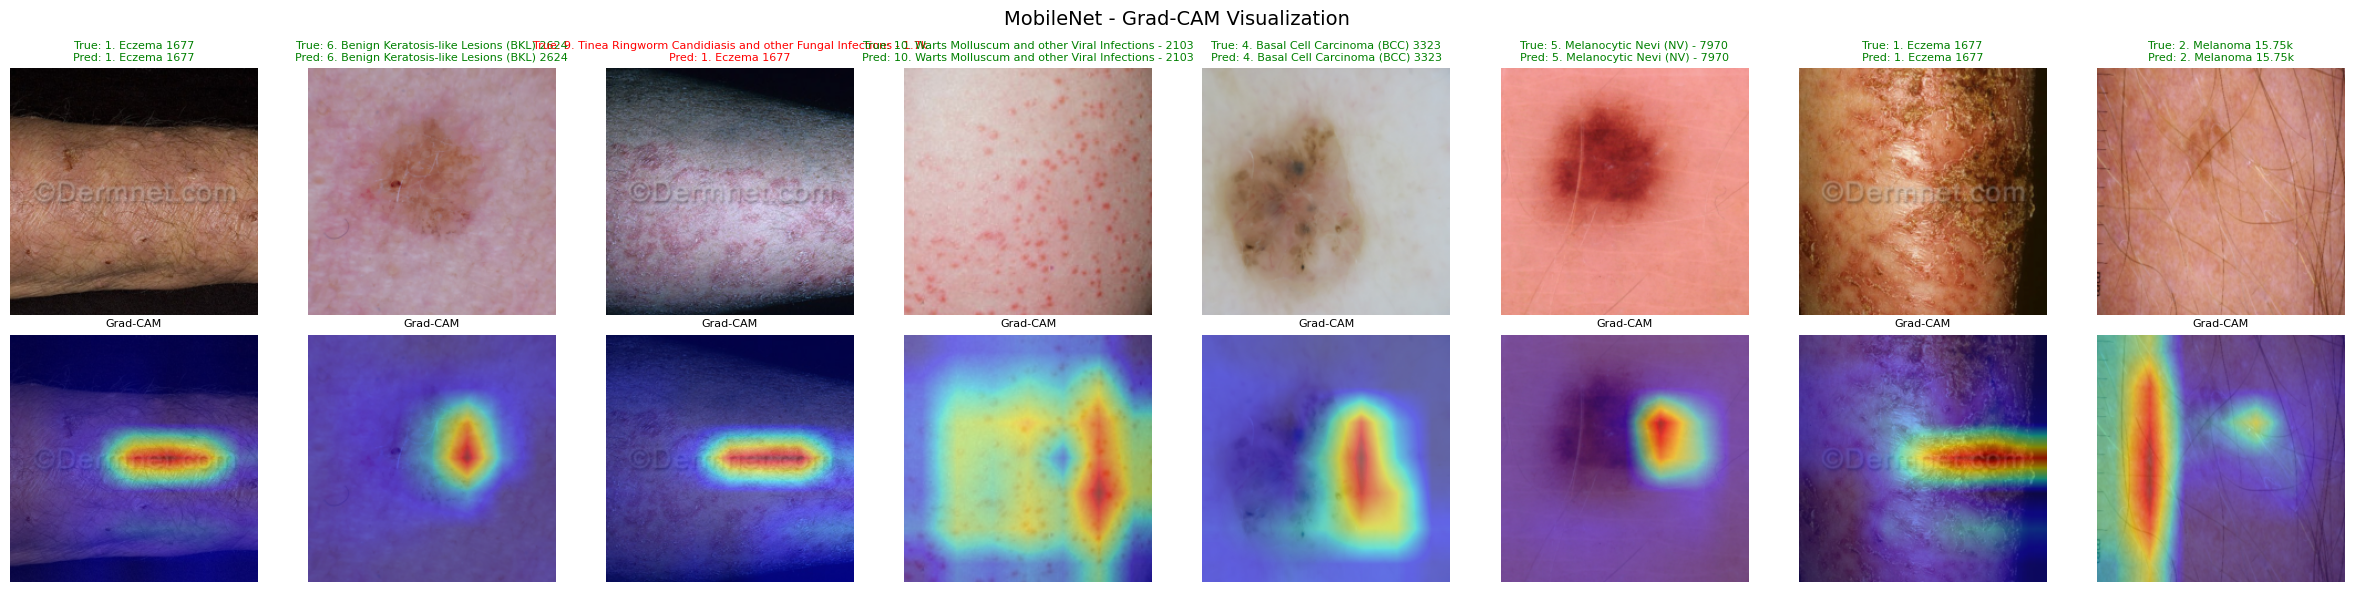


 EfficientNet - Primary Metrics
 Accuracy:          0.8159
 Precision (macro): 0.7491
 Recall (macro):    0.7624
 F1 Score (macro):  0.7539

Per-Class Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.61      0.67      0.64       167
           10. Warts Molluscum and other Viral Infections - 2103       0.74      0.66      0.70       211
                                              2. Melanoma 15.75k       0.96      0.99      0.97       314
                                    3. Atopic Dermatitis - 1.25k       0.53      0.62      0.57       125
                              4. Basal Cell Carcinoma (BCC) 3323       0.89      0.93      0.91       333
                                 5. Melanocytic Nevi (NV) - 7970       0.98      0.90      0.94       797
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.67      0.81      0.74 

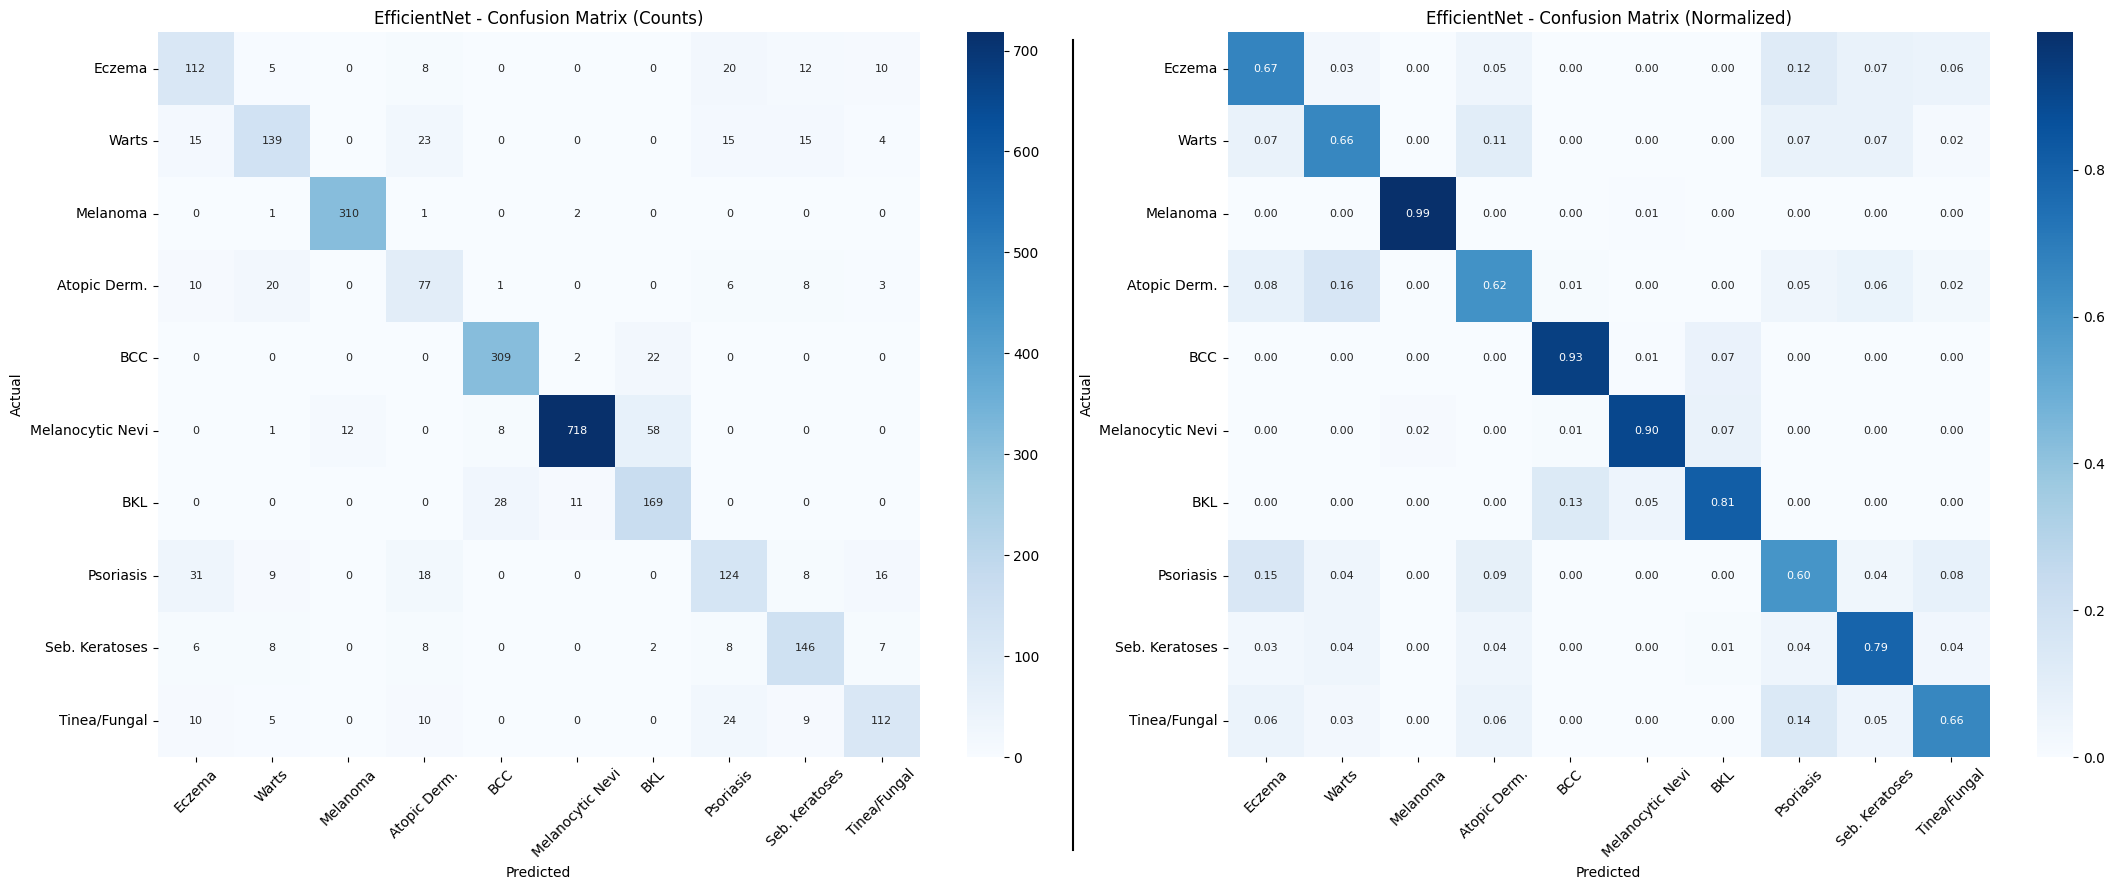

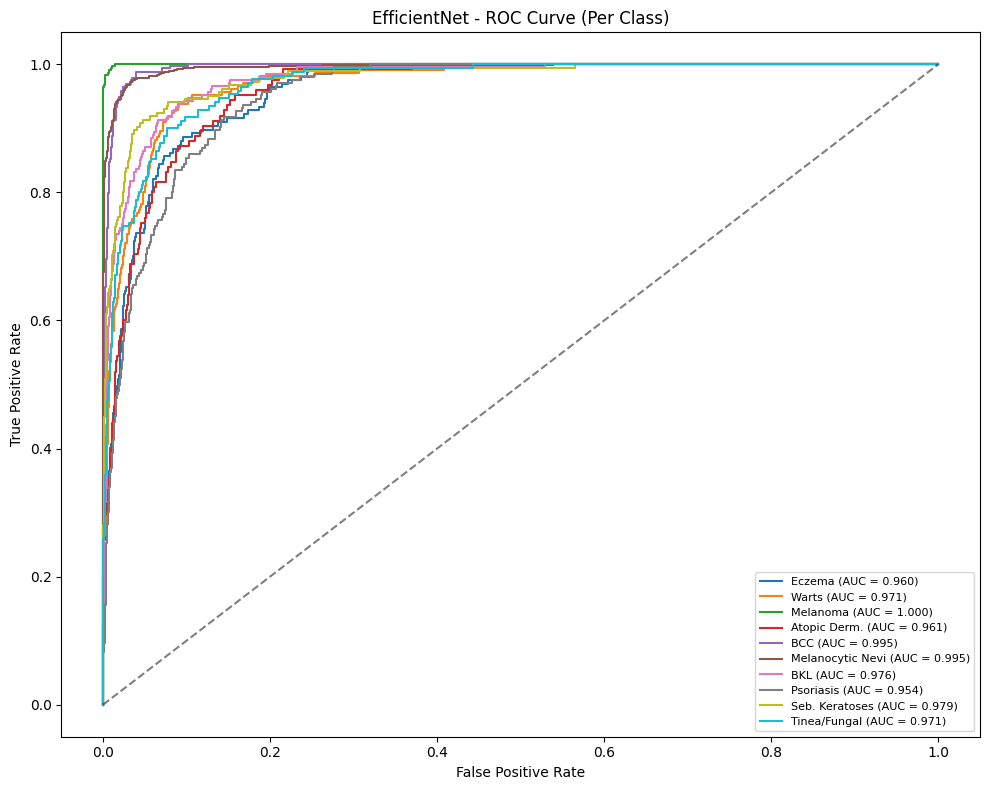


EfficientNet - AUC Scores:
  1. Eczema 1677: 0.9602
  10. Warts Molluscum and other Viral Infections - 2103: 0.9706
  2. Melanoma 15.75k: 0.9998
  3. Atopic Dermatitis - 1.25k: 0.9609
  4. Basal Cell Carcinoma (BCC) 3323: 0.9948
  5. Melanocytic Nevi (NV) - 7970: 0.9950
  6. Benign Keratosis-like Lesions (BKL) 2624: 0.9763
  7. Psoriasis pictures Lichen Planus and related diseases - 2k: 0.9536
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 0.9787
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 0.9709
  Macro AUC: 0.9761

 EfficientNet - Per-Class Error Analysis

  1. Eczema 1677 (167 samples):
    Accuracy: 0.6707 | Correct: 112 | Wrong: 55
    Most confused with -> 7. Psoriasis pictures Lichen Planus and related diseases - 2k: 20, 8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 12, 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 10
    Avg confidence on wrong predictions: 0.7374

  10. Warts Molluscum and other Viral Infections

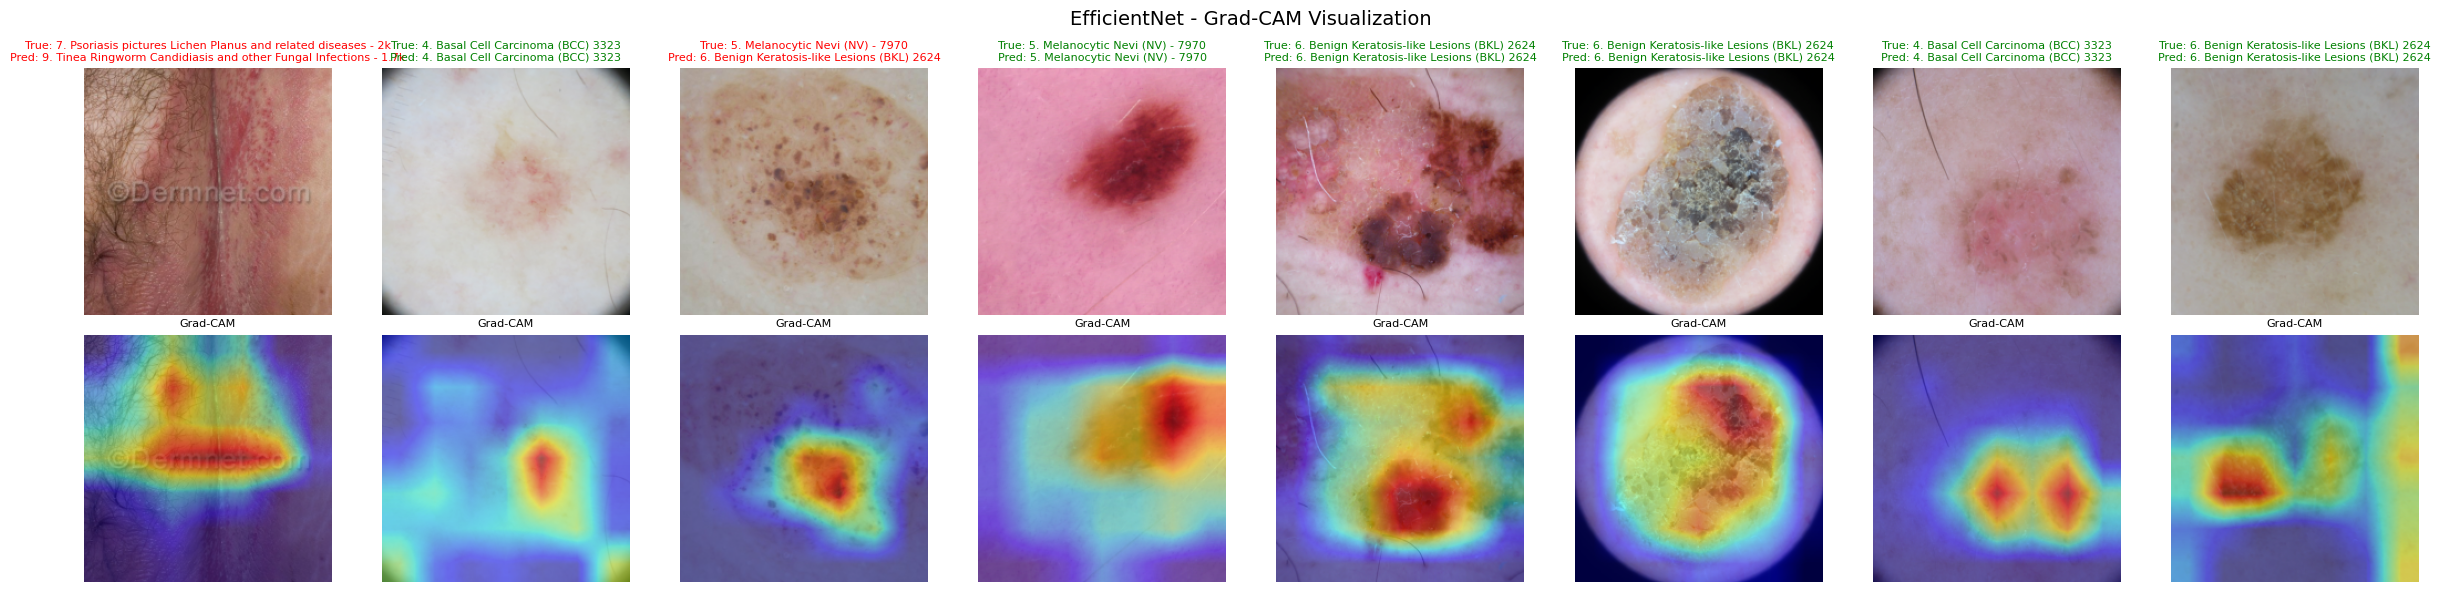

In [56]:
# Run ALl Evaluations

models = {
    "CNN": cnn,
    "MobileNet": mobilenet,
    "EfficientNet": efficientnet
}

all_metrics = {}

for model_name, model in models.items():
    preds, true_labels, probs = evaluate_model(model, test_loader)
    
    metrics = print_primary_metrics(preds, true_labels, model_name)
    all_metrics[model_name] = metrics
    
    plot_confusion_matrix(preds, true_labels, model_name)
    plot_roc_auc(probs, true_labels, model_name)
    per_class_error_analysis(preds, true_labels, probs, model_name)
    plot_gradcam_samples(
        model, model_name, test_paths, test_labels,
        val_transform, class_names, n_samples=8
    )


In [57]:
# Comparison Table

print(f"Model Comparison Summary\n")

print(f"{'Model':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print(f"{'='*70}")
for model_name, m in all_metrics.items():
    print(f"{model_name:<20} {m['accuracy']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f}")
print(f"{'='*70}")

Model Comparison Summary

Model                Accuracy     Precision    Recall       F1          
CNN                  0.5670       0.4285       0.4595       0.4277      
MobileNet            0.7507       0.6686       0.6829       0.6732      
EfficientNet         0.8159       0.7491       0.7624       0.7539      
